[<img src="../XRO_logo.png" width="500">](https://github.com/senclimate/XRO) 

Author: Sen Zhao <zhaos@hawaii.edu>

In this notebook, we will how to calculate the XRO state vectors of climate mode indices.
    
See our paper Zhao et al. 2024[[1]](#1) for details of climate mode indices definitions.

If you encounter problems, please feel free to contact Sen Zhao (zhaos@hawaii.edu).

<a id="1">[1]</a> 
Zhao, S., Jin, F.-F., Stuecker, M.F., Thompson, P.R., Kug, J.-S., McPhaden, M.J., Cane, M.A., Wittenberg, A.T., Cai, W.,. Explainable El Niño predictability from climate mode interactions. Nature. https://doi.org/10.1038/s41586-024-07534-6


In [1]:
%config IPCompleter.greedy = True
%matplotlib inline
%config InlineBackend.figure_format='retina'
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
    
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt

sys.path.append("../")  # adjust to repo root

from XRO.state import CDS_ORAS5_Realtime, calc_XRO_indices

from XRO.stats import detrend

from XRO.core import XRO, lead_to_time


## IMPORTANT: CDS API Setup

To use the Copernicus Climate Data Store (CDS) API, follow the official setup guide:

📘 Documentation: https://cds.climate.copernicus.eu/how-to-api

Step 1 — Create your API key

Log in to your CDS account and obtain your API credentials: https://cds.climate.copernicus.eu/profile

Step 2 — Configure your local credentials

Save your token in the file: ~/.cdsapirc


## Load ORAS5 from CDS realtime data stream

In [2]:
cds = CDS_ORAS5_Realtime()
oras5_data = cds.load_variables(time_slice=slice("1979-01", None))
oras5_data

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 569, lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * time     (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2026-05-01
  * lon      (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Data variables:
    sst      (time, lat, lon) float32 2GB dask.array<chunksize=(12, 64, 62), meta=np.ndarray>
    d20      (time, lat, lon) float32 2GB dask.array<chunksize=(12, 64, 62), meta=np.ndarray>

## Calculate XRO state vectors from ORAS5 data

In [3]:
%%time
XRO_ds = calc_XRO_indices(oras5_data.sst, oras5_data.d20).compute()
XRO_ds

CPU times: user 7.21 s, sys: 1.75 s, total: 8.96 s
Wall time: 14.6 s


<xarray.Dataset> Size: 50kB
Dimensions:  (time: 569)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2026-05-01
Data variables:
    Nino34   (time) float64 5kB 26.53 26.89 27.26 27.97 ... 27.2 28.24 28.93
    WWV      (time) float64 5kB 140.8 138.6 130.9 125.5 ... 134.0 136.8 134.5
    NPMM     (time) float64 5kB 23.9 23.27 23.32 23.67 ... 24.58 25.36 25.72
    SPMM     (time) float64 5kB 24.21 24.64 24.54 24.47 ... 25.07 24.72 23.99
    IOB      (time) float64 5kB 27.98 28.12 28.64 29.09 ... 28.94 29.54 29.32
    IOD      (time) float64 5kB -0.449 -0.6946 -0.2958 ... 0.3705 -0.2472
    SIOD     (time) float64 5kB -1.051 -0.8628 -0.7254 ... -0.4367 -0.1103
    TNA      (time) float64 5kB 24.95 24.78 24.43 24.9 ... 24.33 24.66 25.29
    ATL3     (time) float64 5kB 27.1 27.67 28.27 28.61 ... 28.98 29.36 28.43
    SASD     (time) float64 5kB -8.309 -8.179 -8.322 ... -8.238 -8.484 -9.138

## Calculate anomalies relative to 1991-2020 monthly climatology

In [4]:
clim_slice = slice("1991-01", "2020-12")
XRO_m = XRO_ds.sel(time=clim_slice).groupby('time.month').mean('time')
XRO_a = XRO_ds.groupby('time.month') - XRO_m

# drop unnessary "month" coordinate
XRO_a = XRO_a.drop_vars({'month'})
XRO_a

<xarray.Dataset> Size: 50kB
Dimensions:  (time: 569)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2026-05-01
Data variables:
    Nino34   (time) float64 5kB -0.03267 0.1381 0.009523 ... 0.4043 1.015
    WWV      (time) float64 5kB 13.21 13.11 7.58 4.182 ... 10.68 15.42 14.85
    NPMM     (time) float64 5kB -0.1069 -0.4899 -0.4721 ... 0.7886 1.391 1.296
    SPMM     (time) float64 5kB 0.8241 0.52 0.103 ... 0.6385 0.6592 0.5499
    IOB      (time) float64 5kB 0.01048 -0.04038 -0.09675 ... 0.2908 0.3111
    IOD      (time) float64 5kB 0.3217 -0.05503 -0.06722 ... 0.03446 -0.3478
    SIOD     (time) float64 5kB -0.3227 -0.134 -0.1966 ... -0.2229 -0.1738
    TNA      (time) float64 5kB -0.0595 0.3426 0.04219 ... -0.02613 0.0331
    ATL3     (time) float64 5kB -0.4759 -0.4952 -0.5098 ... 0.2058 0.47 0.3828
    SASD     (time) float64 5kB 0.4324 0.5143 0.5049 ... 0.5887 0.5911 0.09068

## Detrend climate mode indices (use order=1 for linear, order=2 for quadratic)

The choice of detrending method can slightly influence the forecast results. While a linear detrend (order=1) is suitable for most climate mode indices, a quadratic detrend (order=2) is recommended for the WWV index to better account for its long-term nonlinear trend.


In [5]:
%%time
XRO_da = detrend(XRO_a, order=2)
XRO_da

CPU times: user 22.5 ms, sys: 1.05 ms, total: 23.5 ms
Wall time: 23.3 ms


<xarray.Dataset> Size: 50kB
Dimensions:  (time: 569)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2026-05-01
Data variables:
    Nino34   (time) float64 5kB -0.106 0.06562 -0.06205 ... 0.4127 1.022
    WWV      (time) float64 5kB 11.78 11.71 6.197 2.821 ... 5.766 10.47 9.872
    NPMM     (time) float64 5kB -0.2279 -0.609 -0.5892 ... 0.4462 1.046 0.9485
    SPMM     (time) float64 5kB 0.4825 0.1803 -0.2346 ... 0.6651 0.6851 0.5751
    IOB      (time) float64 5kB 0.2039 0.1532 0.097 ... -0.08934 -0.07131
    IOD      (time) float64 5kB 0.4868 0.1095 0.09667 ... 0.2581 0.012 -0.3703
    SIOD     (time) float64 5kB -0.335 -0.1469 -0.2101 ... -0.07551 -0.02524
    TNA      (time) float64 5kB 0.2264 0.6278 0.3267 ... -0.3958 -0.3623 -0.3046
    ATL3     (time) float64 5kB -0.2235 -0.2434 -0.2586 ... 0.145 0.05633
    SASD     (time) float64 5kB 0.4519 0.5349 0.5266 ... 0.2383 0.2383 -0.2645

## plot the XRO climate indices

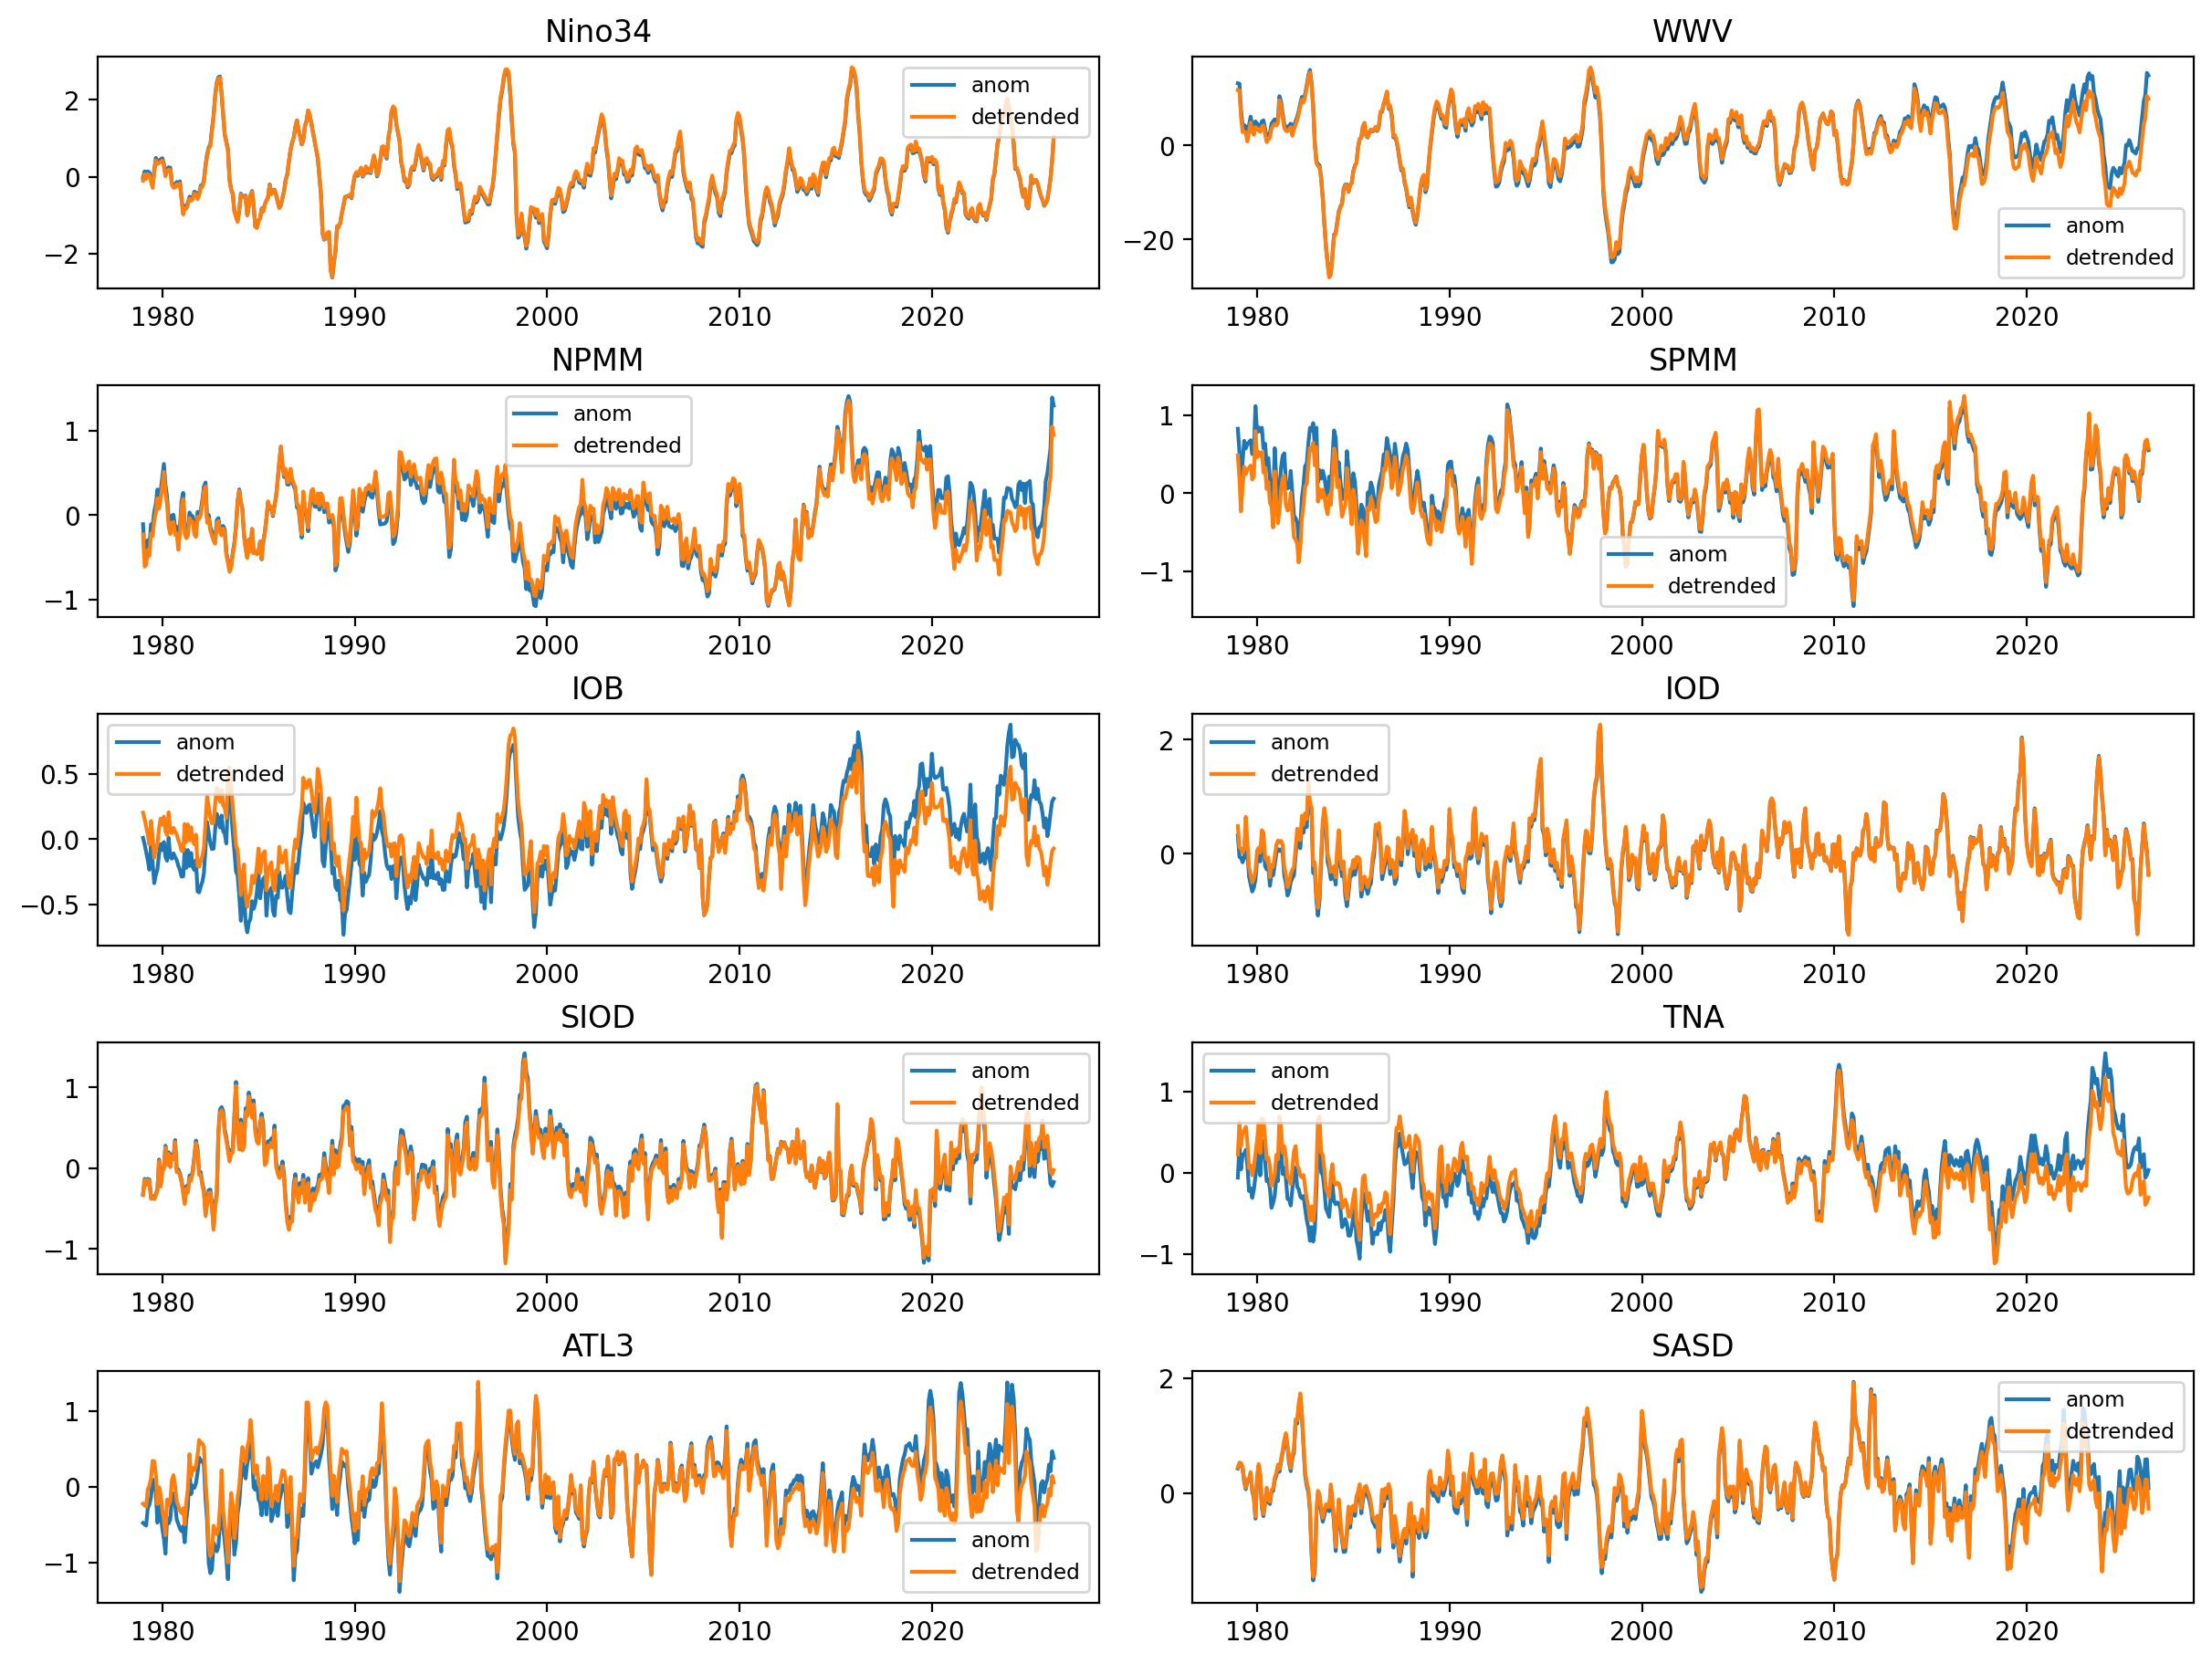

In [6]:
fig, axes = plt.subplots(5, 2, figsize=(12, 9), layout='compressed')

for i, var in enumerate(XRO_a.data_vars):
    ax = axes.flat[i]
    ax.plot(XRO_a.time, XRO_a[var], label='anom')
    ax.plot(XRO_da.time, XRO_da[var], label='detrended')
    ax.set_title(var)
    ax.legend(fontsize='small')


## XRO model fit

In [7]:
XRO_model = XRO(ncycle=12, ac_order=2)
train_slice = slice("1979-01", "2024-12")
maskNT = ['T2', 'TH']
maskNH = []
maskb = ['IOD']

XRO_fit = XRO_model.fit_matrix(XRO_da.sel(time=train_slice), maskNT=maskNT, maskNH=maskNH, maskb=maskb)
XRO_fit

<xarray.Dataset> Size: 210kB
Dimensions:         (ranky: 10, rankx: 10, cycle: 12, ac_rank: 3, cossin: 5,
                     time: 552, nro_form: 5)
Coordinates:
  * rankx           (rankx) int32 40B 1 2 3 4 5 6 7 8 9 10
  * cycle           (cycle) float64 96B 0.04167 0.125 0.2083 ... 0.875 0.9583
  * ac_rank         (ac_rank) int32 12B 0 1 2
  * cossin          (cossin) int32 20B 0 1 2 3 4
  * time            (time) float64 4kB 0.04167 0.125 0.2083 ... 45.88 45.96
  * ranky           (ranky) int32 40B 1 2 3 4 5 6 7 8 9 10
  * nro_form        (nro_form) <U3 60B 'T2' 'TH' 'T3' 'T2H' 'TH2'
Data variables: (12/31)
    Lac             (ranky, rankx, cycle) float64 10kB -2.201 -2.011 ... -1.878
    Lcomp           (ranky, rankx, cycle, ac_rank) float64 29kB -0.9207 ... 0...
    Lcoef           (ranky, rankx, cossin) float64 4kB -0.9207 ... -0.5139
    X               (rankx, time) float64 44kB -0.106 0.06562 ... -0.6972
    Y               (ranky, time) float64 44kB 2.06 -1.532 ... -9.257 -9.257
    Yfit            (ranky, time) float64 44kB 0.171 -0.1465 ... 0.6367 1.88
    ...              ...
    NROT_Lcoef      (nro_form, cossin) float64 200B 0.04948 -0.2266 ... 0.0 0.0
    NROT_Lcomp      (nro_form, cycle, ac_rank) float64 1kB 0.04948 ... 0.0
    NROH_Lac        (nro_form, cycle) float64 480B 0.0 0.0 0.0 ... 0.0 0.0 0.0
    NROH_Lcoef      (nro_form, cossin) float64 200B 0.0 0.0 0.0 ... 0.0 0.0 0.0
    NROH_Lcomp      (nro_form, cycle, ac_rank) float64 1kB 0.0 0.0 ... 0.0 0.0
    var_names       (ranky) <U6 240B 'Nino34' 'WWV' 'NPMM' ... 'ATL3' 'SASD'

## XRO realtime forecasts

In [8]:
fcst_slice = slice("2026-01", None)
XRO_fcst = XRO_model.reforecast(fit_ds=XRO_fit, init_ds=XRO_da.sel(time=fcst_slice), n_month=18, noise_type='zero')
XRO_fcst

<xarray.Dataset> Size: 8kB
Dimensions:  (init: 5, lead: 19)
Coordinates:
  * init     (init) datetime64[ns] 40B 2026-01-01 2026-02-01 ... 2026-05-01
  * lead     (lead) int32 76B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18
Data variables:
    Nino34   (init, lead) float64 760B -0.6008 -0.5095 ... -0.5147 -0.6339
    WWV      (init, lead) float64 760B 1.286 2.086 3.093 ... -11.89 -11.58
    NPMM     (init, lead) float64 760B 0.1581 0.1631 0.1733 ... 0.3685 0.281
    SPMM     (init, lead) float64 760B 0.2742 0.257 0.2104 ... 0.138 0.1094
    IOB      (init, lead) float64 760B -0.3501 -0.2924 ... 0.08024 -0.003807
    IOD      (init, lead) float64 760B 0.1108 0.1201 0.1156 ... -0.4621 -0.4803
    SIOD     (init, lead) float64 760B 0.402 0.2816 0.1233 ... 0.112 0.2164
    TNA      (init, lead) float64 760B -0.1882 -0.2001 ... 0.008167 0.01176
    ATL3     (init, lead) float64 760B -0.2216 -0.1766 -0.1258 ... 0.233 0.1989
    SASD     (init, lead) float64 760B -0.339 -0.3146 ... -0.3234 -0.2149

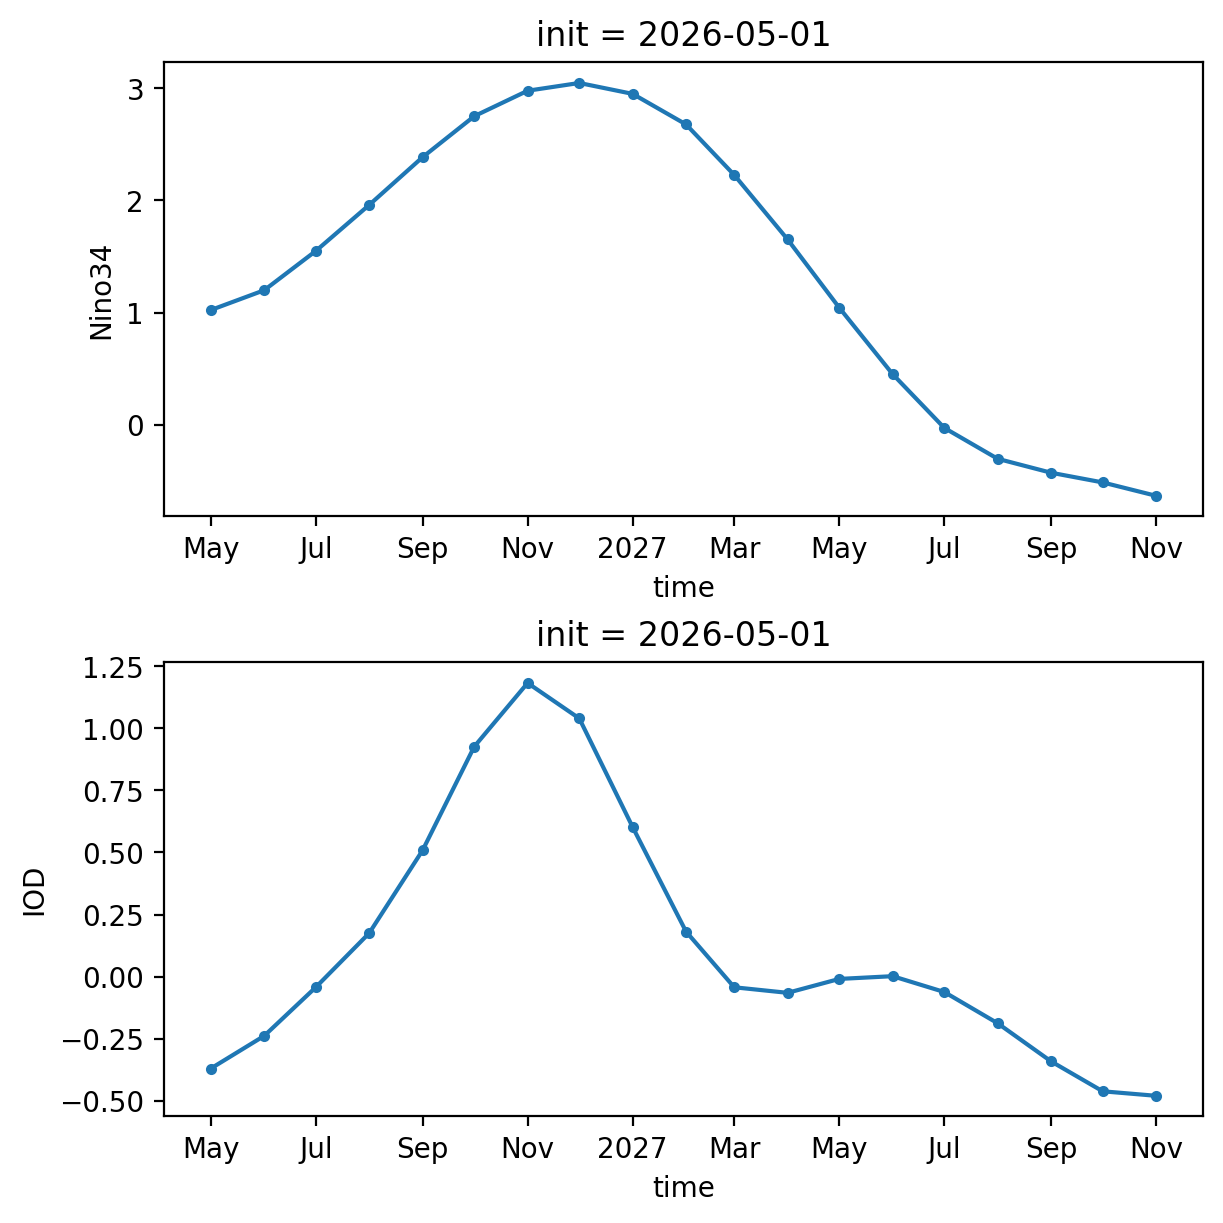

In [9]:
XRO_latest_fcst = lead_to_time(XRO_fcst.isel(init=-1))

fig = plt.figure(figsize=(6, 6), layout='compressed')
plt.subplot(2, 1, 1)
XRO_latest_fcst['Nino34'].plot(marker='.')

plt.subplot(2, 1, 2)
XRO_latest_fcst['IOD'].plot(marker='.')